# Multi-Regressor Modeling Merapi (Input dari SMOTE Pipeline)
Notebook ini memuat data hasil preprocessing+augmentasi SMOTE-style dari folder merapi, kemudian melatih model multi-output untuk target:
- jarak_km
- luas_km2
- sudut_deg
- radius_km

Alur:
1. Load train_aug/val/test
2. Standardisasi fitur dan target (fit di train)
3. Training beberapa kandidat model multi-output
4. Pilih model terbaik berdasarkan rata-rata R2 di validation
5. Evaluasi final di test + simpan artefak

In [12]:
from pathlib import Path
from time import perf_counter
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

In [13]:
# Konfigurasi path
step_start = perf_counter()

INPUT_DIR = Path('preprocessing_outputs_merapi_smote_v2')
TRAIN_PATH = INPUT_DIR / 'merapi_train_augmented_smote.csv'
VAL_PATH = INPUT_DIR / 'merapi_val_smote.csv'
TEST_PATH = INPUT_DIR / 'merapi_test_smote.csv'

ARTIFACT_DIR = Path('artifacts_multi_regressor_merapi_smote_v2')
SPLIT_DIR = ARTIFACT_DIR / 'splits'
SCALER_DIR = ARTIFACT_DIR / 'scalers'
MODEL_DIR = ARTIFACT_DIR / 'model'
METRIC_DIR = ARTIFACT_DIR / 'metrics'

for d in [ARTIFACT_DIR, SPLIT_DIR, SCALER_DIR, MODEL_DIR, METRIC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET_COLS = ['jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']
process_times = {}

process_times['setup_paths'] = perf_counter() - step_start
print(f'Waktu setup_paths: {process_times["setup_paths"]:.6f} detik')
print('Train path:', TRAIN_PATH.resolve())
print('Val path  :', VAL_PATH.resolve())
print('Test path :', TEST_PATH.resolve())

Waktu setup_paths: 0.002480 detik
Train path: D:\Projects\volcanic_ash\merapi\preprocessing_outputs_merapi_smote_v2\merapi_train_augmented_smote.csv
Val path  : D:\Projects\volcanic_ash\merapi\preprocessing_outputs_merapi_smote_v2\merapi_val_smote.csv
Test path : D:\Projects\volcanic_ash\merapi\preprocessing_outputs_merapi_smote_v2\merapi_test_smote.csv


In [14]:
# Load data train/val/test
step_start = perf_counter()

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'File tidak ditemukan: {p}')

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for dfx in [train_df, val_df, test_df]:
    dfx.columns = [c.strip() for c in dfx.columns]

for split_name, dfx in [('train', train_df), ('val', val_df), ('test', test_df)]:
    missing_targets = [c for c in TARGET_COLS if c not in dfx.columns]
    if missing_targets:
        raise ValueError(f'Target tidak ditemukan di {split_name}: {missing_targets}')

process_times['load_data'] = perf_counter() - step_start
print(f'Waktu load_data: {process_times["load_data"]:.6f} detik')
print('Shape train:', train_df.shape)
print('Shape val  :', val_df.shape)
print('Shape test :', test_df.shape)
display(train_df.head(3))

Waktu load_data: 0.068713 detik
Shape train: (150, 18)
Shape val  : (8, 18)
Shape test : (9, 18)


,eruption_energy_proxy,tinggi_letusan_m,plume_to_elevation_ratio,amplitudo,wind_plume_interaction,month_cos,wind_v,month,month_sin,arah_angin_deg,duration_amplitude_interaction,hour_sin,wind_u,kec_angin_km_jam,jarak_km,luas_km2,sudut_deg,radius_km
0,470800.0,11770.0,3.964298,40.0,21186.0,5.551115e-17,-1.8,3.0,1.000000,270.0,7200.0,-0.500000,-3.330669e-16,1.8,58.845740,552.565925,229.117974,30.621051
1,748500.0,14970.0,5.042102,50.0,46407.0,5.551115e-17,-3.1,3.0,1.000000,270.0,9000.0,-0.500000,-5.828671e-16,3.1,69.898476,675.517531,258.607262,38.636533
2,39600.0,600.0,0.202088,66.0,6120.0,-5.000000e-01,-10.2,8.0,-0.866025,270.0,19074.0,-0.258819,-1.887379e-15,10.2,35.719180,645.110183,305.709856,19.841631


In [15]:
# Siapkan fitur dan target
step_start = perf_counter()

feature_cols = [c for c in train_df.columns if c not in TARGET_COLS]

missing_feature_cols_val = [c for c in feature_cols if c not in val_df.columns]
missing_feature_cols_test = [c for c in feature_cols if c not in test_df.columns]
if missing_feature_cols_val or missing_feature_cols_test:
    raise ValueError(
        'Kolom fitur train/val/test tidak konsisten. ' +
        f'Missing di val: {missing_feature_cols_val}; Missing di test: {missing_feature_cols_test}'
    )

X_train = train_df[feature_cols].copy()
X_val = val_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[TARGET_COLS].copy()
y_val = val_df[TARGET_COLS].copy()
y_test = test_df[TARGET_COLS].copy()

process_times['prepare_xy'] = perf_counter() - step_start
print(f'Waktu prepare_xy: {process_times["prepare_xy"]:.6f} detik')
print('Jumlah fitur:', len(feature_cols))
print('Fitur:', feature_cols)

Waktu prepare_xy: 0.007502 detik
Jumlah fitur: 14
Fitur: ['eruption_energy_proxy', 'tinggi_letusan_m', 'plume_to_elevation_ratio', 'amplitudo', 'wind_plume_interaction', 'month_cos', 'wind_v', 'month', 'month_sin', 'arah_angin_deg', 'duration_amplitude_interaction', 'hour_sin', 'wind_u', 'kec_angin_km_jam']


In [16]:
# Standardisasi (fit hanya di train)
step_start = perf_counter()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = pd.DataFrame(x_scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_scaled = pd.DataFrame(x_scaler.transform(X_val), columns=feature_cols, index=X_val.index)
X_test_scaled = pd.DataFrame(x_scaler.transform(X_test), columns=feature_cols, index=X_test.index)

y_train_scaled = pd.DataFrame(y_scaler.fit_transform(y_train), columns=TARGET_COLS, index=y_train.index)
y_val_scaled = pd.DataFrame(y_scaler.transform(y_val), columns=TARGET_COLS, index=y_val.index)
y_test_scaled = pd.DataFrame(y_scaler.transform(y_test), columns=TARGET_COLS, index=y_test.index)

process_times['scaling'] = perf_counter() - step_start
print(f'Waktu scaling: {process_times["scaling"]:.6f} detik')
print('Standardisasi selesai.')

Waktu scaling: 0.010595 detik
Standardisasi selesai.


In [17]:
# Simpan split raw + scaled dan scaler
step_start = perf_counter()

X_train.to_csv(SPLIT_DIR / 'X_train_raw.csv', index=False)
X_val.to_csv(SPLIT_DIR / 'X_val_raw.csv', index=False)
X_test.to_csv(SPLIT_DIR / 'X_test_raw.csv', index=False)
y_train.to_csv(SPLIT_DIR / 'y_train_raw.csv', index=False)
y_val.to_csv(SPLIT_DIR / 'y_val_raw.csv', index=False)
y_test.to_csv(SPLIT_DIR / 'y_test_raw.csv', index=False)

X_train_scaled.to_csv(SPLIT_DIR / 'X_train_scaled.csv', index=False)
X_val_scaled.to_csv(SPLIT_DIR / 'X_val_scaled.csv', index=False)
X_test_scaled.to_csv(SPLIT_DIR / 'X_test_scaled.csv', index=False)
y_train_scaled.to_csv(SPLIT_DIR / 'y_train_scaled.csv', index=False)
y_val_scaled.to_csv(SPLIT_DIR / 'y_val_scaled.csv', index=False)
y_test_scaled.to_csv(SPLIT_DIR / 'y_test_scaled.csv', index=False)

with open(SCALER_DIR / 'x_scaler.pkl', 'wb') as f:
    pickle.dump(x_scaler, f)
with open(SCALER_DIR / 'y_scaler.pkl', 'wb') as f:
    pickle.dump(y_scaler, f)

scaler_metadata = {
    'feature_cols': feature_cols,
    'target_cols': TARGET_COLS,
    'x_scaler_mean': x_scaler.mean_.tolist(),
    'x_scaler_scale': x_scaler.scale_.tolist(),
    'y_scaler_mean': y_scaler.mean_.tolist(),
    'y_scaler_scale': y_scaler.scale_.tolist()
}
with open(SCALER_DIR / 'scaler_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(scaler_metadata, f, indent=2)

process_times['save_splits_and_scalers'] = perf_counter() - step_start
print(f'Waktu save_splits_and_scalers: {process_times["save_splits_and_scalers"]:.6f} detik')

Waktu save_splits_and_scalers: 0.076344 detik


In [18]:
# Definisi kandidat model
step_start = perf_counter()

model_candidates = {
    'dummy_mean': DummyRegressor(strategy='mean'),
    'ridge': MultiOutputRegressor(
        Ridge(alpha=1.0, random_state=RANDOM_STATE)
    ),
    'elastic_net': MultiOutputRegressor(
        ElasticNet(alpha=0.05, l1_ratio=0.2, random_state=RANDOM_STATE, max_iter=5000)
    ),
    'xgboost': MultiOutputRegressor(
        XGBRegressor(
            n_estimators=240,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.2,
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    'random_forest': MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=350,
            max_depth=8,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    'extra_trees': MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=450,
            max_depth=8,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
}

cv = RepeatedKFold(n_splits=4, n_repeats=3, random_state=RANDOM_STATE)

process_times['build_candidates'] = perf_counter() - step_start
print(f'Waktu build_candidates: {process_times["build_candidates"]:.6f} detik')
print('Kandidat model:', list(model_candidates.keys()))

Waktu build_candidates: 0.000637 detik
Kandidat model: ['dummy_mean', 'ridge', 'elastic_net', 'xgboost', 'random_forest', 'extra_trees']


In [19]:
# Training kandidat dan evaluasi di validation + repeated CV
step_start = perf_counter()

def evaluate_predictions(y_true_df: pd.DataFrame, y_pred_raw: np.ndarray, split_name: str, model_name: str):
    rows = []
    for i, target in enumerate(TARGET_COLS):
        y_true = y_true_df[target].values
        y_pred = y_pred_raw[:, i]

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        rows.append({
            'model': model_name,
            'split': split_name,
            'target': target,
            'MAE': float(mae),
            'RMSE': float(rmse),
            'R2': float(r2)
        })
    return pd.DataFrame(rows)

trained_models = {}
val_metric_tables = []
cv_rows = []

for name, model in model_candidates.items():
    print(f'Latih model: {name}')

    # Repeated CV di train untuk menstabilkan estimasi performa
    cv_scores = cross_val_score(
        clone(model),
        X_train_scaled,
        y_train_scaled,
        scoring='r2',
        cv=cv,
        n_jobs=-1
    )
    cv_r2_mean = float(np.mean(cv_scores))
    cv_r2_std = float(np.std(cv_scores))
    cv_rows.append({'model': name, 'cv_r2_mean': cv_r2_mean, 'cv_r2_std': cv_r2_std})

    # Fit full train, evaluasi di validation
    model.fit(X_train_scaled, y_train_scaled)
    trained_models[name] = model

    y_val_pred_scaled = model.predict(X_val_scaled)
    y_val_pred_raw = y_scaler.inverse_transform(y_val_pred_scaled)

    val_metrics = evaluate_predictions(y_val, y_val_pred_raw, split_name='val', model_name=name)
    val_metric_tables.append(val_metrics)

val_metrics_all = pd.concat(val_metric_tables, ignore_index=True)
val_summary = (
    val_metrics_all.groupby('model')[['MAE', 'RMSE', 'R2']]
    .mean()
    .reset_index()
)
cv_summary = pd.DataFrame(cv_rows)

selection_table = val_summary.merge(cv_summary, on='model', how='left')
selection_table['selection_score'] = 0.4 * selection_table['R2'] + 0.6 * selection_table['cv_r2_mean']
selection_table = selection_table.sort_values(
    ['selection_score', 'cv_r2_mean', 'RMSE'],
    ascending=[False, False, True]
).reset_index(drop=True)

best_model_name = selection_table.iloc[0]['model']
best_model = trained_models[best_model_name]

with open(MODEL_DIR / f'best_model_{best_model_name}.pkl', 'wb') as f:
    pickle.dump(best_model, f)

selection_info = {
    'best_model': best_model_name,
    'selection_criteria': '0.4*val_R2 + 0.6*repeated_cv_R2; tie-breaker RMSE',
    'cv_scheme': {'n_splits': 4, 'n_repeats': 3}
}
with open(MODEL_DIR / 'model_selection.json', 'w', encoding='utf-8') as f:
    json.dump(selection_info, f, indent=2)

val_metrics_all.to_csv(METRIC_DIR / 'val_metrics_per_target_all_models.csv', index=False)
val_summary.to_csv(METRIC_DIR / 'val_model_summary.csv', index=False)
cv_summary.to_csv(METRIC_DIR / 'cv_model_summary.csv', index=False)
selection_table.to_csv(METRIC_DIR / 'model_selection_table.csv', index=False)

process_times['train_and_validate'] = perf_counter() - step_start
print(f'Waktu train_and_validate: {process_times["train_and_validate"]:.6f} detik')
print('Best model:', best_model_name)
display(selection_table)
display(val_metrics_all.head(18))

Latih model: dummy_mean
Latih model: ridge
Latih model: elastic_net
Latih model: xgboost
Latih model: random_forest
Latih model: extra_trees
Waktu train_and_validate: 25.645549 detik
Best model: extra_trees


,model,MAE,RMSE,R2,cv_r2_mean,cv_r2_std,selection_score
0,extra_trees,190.194855,220.940045,-0.418344,0.931663,0.034361,0.391660
1,xgboost,277.144061,352.426959,-1.194692,0.901992,0.064236,0.063318
2,random_forest,263.519913,348.535682,-1.520629,0.866628,0.069351,-0.088275
3,elastic_net,253.637301,302.205244,-2.334528,0.679033,0.090294,-0.526391
4,dummy_mean,291.578586,311.331364,-1.711730,-0.043521,0.032811,-0.710804
5,ridge,269.467729,344.255091,-2.807710,0.632142,0.158974,-0.743799


,model,split,target,MAE,RMSE,R2
0,dummy_mean,val,jarak_km,39.164536,44.384411,-0.575039
1,dummy_mean,val,luas_km2,1065.079676,1131.202175,-2.315245
2,dummy_mean,val,sudut_deg,39.004660,44.416610,-3.369787
3,dummy_mean,val,radius_km,23.065473,25.322257,-0.586851
4,ridge,val,jarak_km,33.020027,39.405762,-0.241509
5,ridge,val,luas_km2,972.475129,1254.895185,-3.079905
6,ridge,val,sudut_deg,56.804934,63.840541,-8.027397
7,ridge,val,radius_km,15.570827,18.878878,0.117970
8,elastic_net,val,jarak_km,29.188664,34.579432,0.043982
9,elastic_net,val,luas_km2,918.059679,1095.539752,-2.109506


In [20]:
# Evaluasi final di test untuk best model
step_start = perf_counter()

y_test_pred_scaled = best_model.predict(X_test_scaled)
y_test_pred_raw = y_scaler.inverse_transform(y_test_pred_scaled)

test_metrics = evaluate_predictions(y_test, y_test_pred_raw, split_name='test', model_name=best_model_name)
test_summary = test_metrics.groupby(['model', 'split'])[['MAE', 'RMSE', 'R2']].mean().reset_index()

test_metrics.to_csv(METRIC_DIR / 'test_metrics_per_target.csv', index=False)
test_summary.to_csv(METRIC_DIR / 'test_summary.csv', index=False)

test_predictions = pd.DataFrame(y_test_pred_raw, columns=[f'{c}_pred' for c in TARGET_COLS])
test_actual = y_test.reset_index(drop=True).copy()
pred_vs_actual = pd.concat([test_actual, test_predictions], axis=1)
pred_vs_actual.to_csv(METRIC_DIR / 'test_predictions_vs_actual.csv', index=False)

process_times['evaluate_test'] = perf_counter() - step_start
print(f'Waktu evaluate_test: {process_times["evaluate_test"]:.6f} detik')
display(test_metrics)
display(test_summary)

Waktu evaluate_test: 0.283026 detik


,model,split,target,MAE,RMSE,R2
0,extra_trees,test,jarak_km,30.950334,44.676607,0.182273
1,extra_trees,test,luas_km2,652.102637,946.579226,0.180149
2,extra_trees,test,sudut_deg,38.172738,57.408394,0.299740
3,extra_trees,test,radius_km,18.269093,26.902782,0.193948


,model,split,MAE,RMSE,R2
0,extra_trees,test,184.873701,268.891753,0.214028


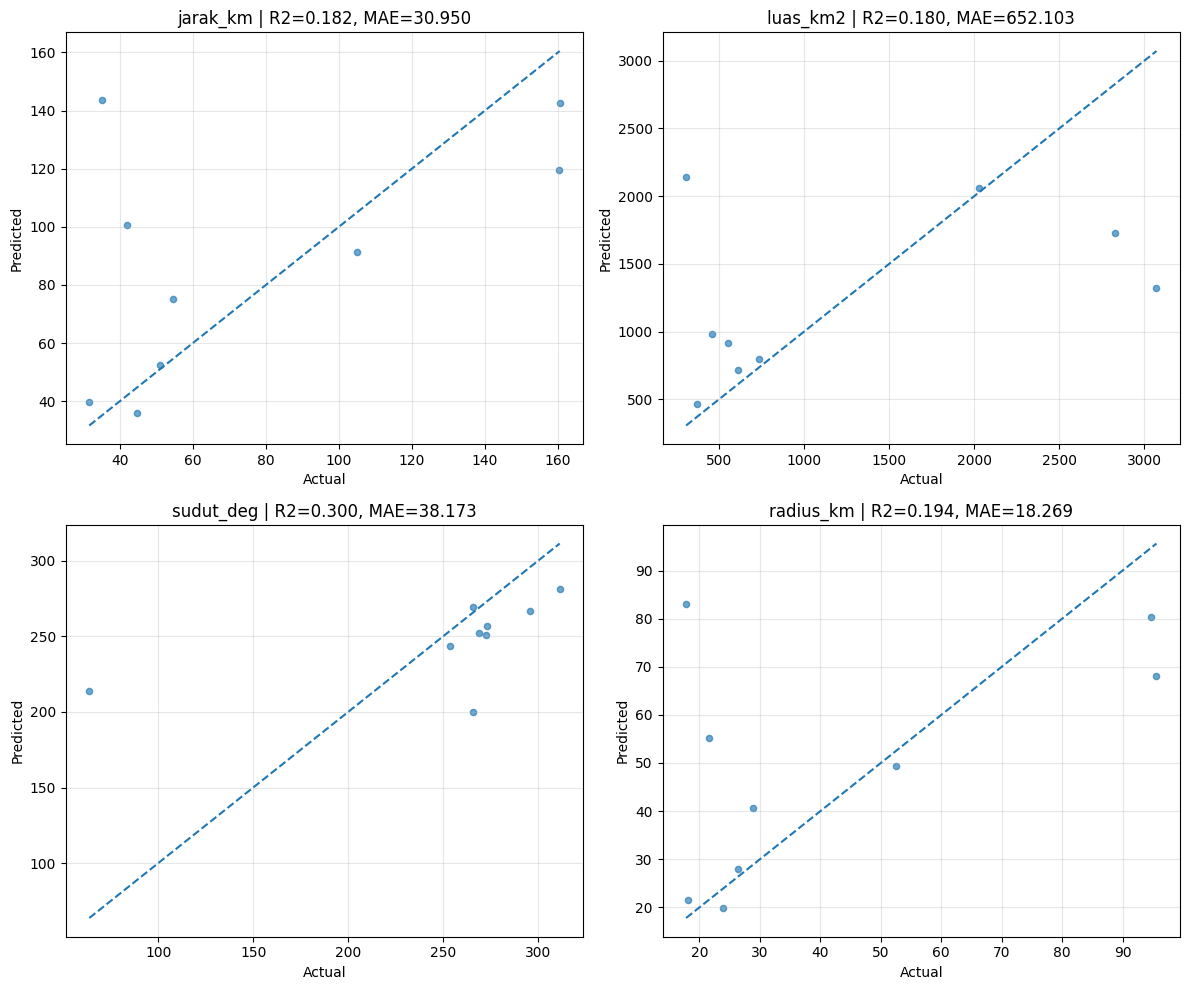

Waktu plot_test: 1.099254 detik


In [21]:
# Plot aktual vs prediksi pada test
step_start = perf_counter()

n_targets = len(TARGET_COLS)
n_cols = 2
n_rows = (n_targets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, target in enumerate(TARGET_COLS):
    ax = axes[i]
    y_true = y_test[target].values
    y_pred = y_test_pred_raw[:, i]

    ax.scatter(y_true, y_pred, alpha=0.65, s=20)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1.5)

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_title(f'{target} | R2={r2:.3f}, MAE={mae:.3f}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(alpha=0.3)

for j in range(n_targets, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
fig.savefig(METRIC_DIR / 'test_regression_plots.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

process_times['plot_test'] = perf_counter() - step_start
print(f'Waktu plot_test: {process_times["plot_test"]:.6f} detik')

In [22]:
# Ringkasan artefak dan waktu proses
step_start = perf_counter()

saved_files = sorted([str(p) for p in ARTIFACT_DIR.rglob('*') if p.is_file()])
print('Daftar file artefak:')
for f in saved_files:
    print('-', f)

timing_df = pd.DataFrame([{'process': k, 'duration_seconds': v} for k, v in process_times.items()])
timing_df = timing_df.sort_values('duration_seconds', ascending=False).reset_index(drop=True)
timing_df.to_csv(METRIC_DIR / 'process_times.csv', index=False)

process_times['list_artifacts'] = perf_counter() - step_start
print(f'Waktu list_artifacts: {process_times["list_artifacts"]:.6f} detik')
display(timing_df)

Daftar file artefak:
- artifacts_multi_regressor_merapi_smote_v2\metrics\cv_model_summary.csv
- artifacts_multi_regressor_merapi_smote_v2\metrics\model_selection_table.csv
- artifacts_multi_regressor_merapi_smote_v2\metrics\test_metrics_per_target.csv
- artifacts_multi_regressor_merapi_smote_v2\metrics\test_predictions_vs_actual.csv
- artifacts_multi_regressor_merapi_smote_v2\metrics\test_regression_plots.png
- artifacts_multi_regressor_merapi_smote_v2\metrics\test_summary.csv
- artifacts_multi_regressor_merapi_smote_v2\metrics\val_metrics_per_target_all_models.csv
- artifacts_multi_regressor_merapi_smote_v2\metrics\val_model_summary.csv
- artifacts_multi_regressor_merapi_smote_v2\model\best_model_extra_trees.pkl
- artifacts_multi_regressor_merapi_smote_v2\model\model_selection.json
- artifacts_multi_regressor_merapi_smote_v2\scalers\scaler_metadata.json
- artifacts_multi_regressor_merapi_smote_v2\scalers\x_scaler.pkl
- artifacts_multi_regressor_merapi_smote_v2\scalers\y_scaler.pkl
- a

,process,duration_seconds
0,train_and_validate,25.645549
1,plot_test,1.099254
2,evaluate_test,0.283026
3,save_splits_and_scalers,0.076344
4,load_data,0.068713
5,scaling,0.010595
6,prepare_xy,0.007502
7,setup_paths,0.002480
8,build_candidates,0.000637
